<a href="https://colab.research.google.com/github/Mangalure1008/Deeplearning/blob/main/Convolutional_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)


In [4]:
class_names = [
 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Number of classes:", len(class_names))

Number of classes: 10


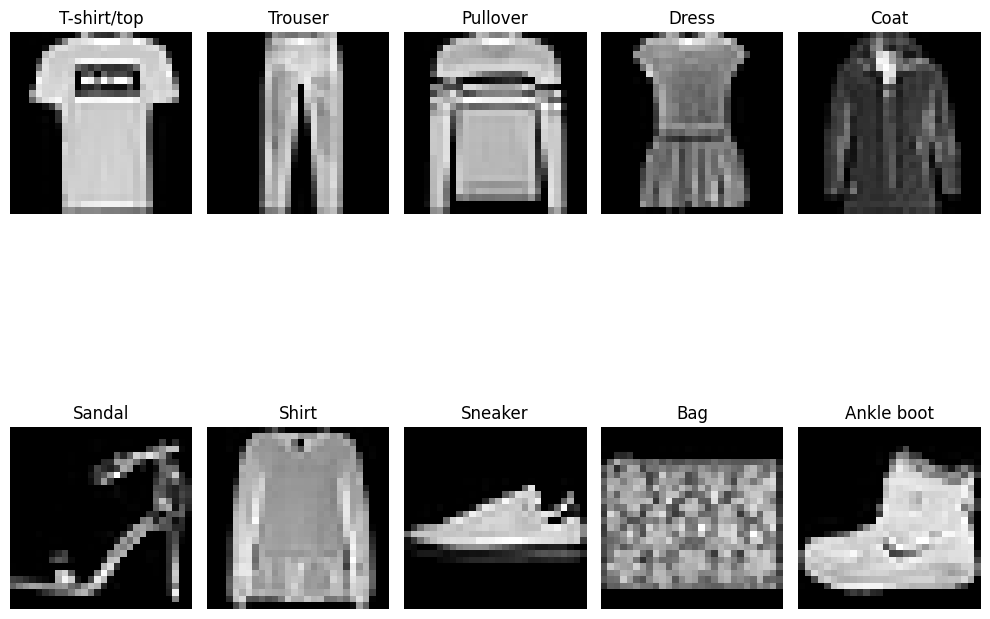

In [5]:
plt.figure(figsize=(10, 10))

for i in range(10):
    # Find first image of each class
    index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# Add channel dimension (for grayscale = 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New x_train shape:", x_train.shape)
print("New x_test shape :", x_test.shape)

New x_train shape: (60000, 28, 28, 1)
New x_test shape : (10000, 28, 28, 1)


Question 1-Why is normalization required for image data?

Answer - Normalization is required to convert pixel values from a large range (0–255) to a smaller and consistent range (0-1).

Reasons:
Faster training: Smaller values help the model converge more quickly.
Better numerical stability: Prevents large gradients that can disrupt learning.
Improved performance: Ensures all features contribute equally instead of larger values dominating.
Efficient optimization: Gradient descent works better when inputs are scaled.

Question 2-Why do CNNs require reshaped image inputs?

Answer - CNNs require input data in a specific 4D format:
(samples, height, width, channels)

Channel information: CNN layers expect a channel dimension (e.g., 1 for grayscale, 3 for RGB).
Convolution operation: Filters slide across height and width and process channels simultaneously.
Compatibility with deep learning frameworks: Libraries like TensorFlow/Keras strictly require this format.

Example:
Before reshape:
(60000, 28, 28)

After reshape:
(60000, 28, 28, 1)

The extra 1 represents the grayscale channel.

In [8]:
# Part 2 : Build the Shallow CNN Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build shallow CNN model
model = Sequential()

# 1st Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Hidden Layer
model.add(Dense(128, activation='relu'))

# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model Complilation

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train the Model

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8545 - loss: 0.4086 - val_accuracy: 0.8882 - val_loss: 0.3160
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8988 - loss: 0.2806 - val_accuracy: 0.8888 - val_loss: 0.3042
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9140 - loss: 0.2342 - val_accuracy: 0.9068 - val_loss: 0.2656
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9263 - loss: 0.2014 - val_accuracy: 0.9099 - val_loss: 0.2494
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.9358 - loss: 0.1746 - val_accuracy: 0.9013 - val_loss: 0.2829
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9466 - loss: 0.1479 - val_accuracy: 0.9116 - val_loss: 0.2662
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.9527 - loss: 0.1282 - val_accuracy: 0.9132 - val_loss: 0.2616
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9608 -

In [11]:
# Evaluate on Test Data

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9127 - loss: 0.3309
Test Accuracy: 0.9126999974250793


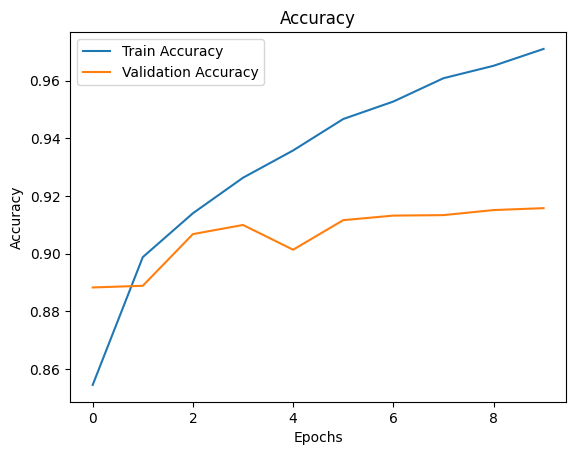

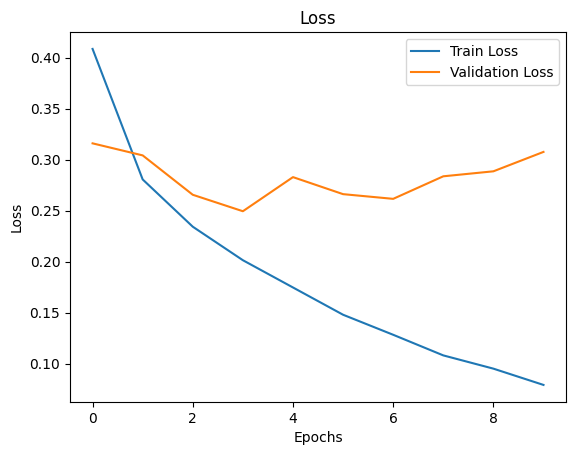

In [12]:
# Accuracy Plot & Loss

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Question 1- What kind of patterns do you expect a shallow CNN to learn?

Answer -
A shallow CNN learns basic visual patterns such as edges, outlines, and simple textures. It captures low-level features but struggles with complex object representations.

Question 2- Did the model show signs of underfitting or overfitting?

Answer - If the Training Model is greater than Validation Model, then it shows the Overfitting.

In [13]:
# Part 3 : Build the Deep CNN Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build deep CNN model
deep_model = Sequential()

# Block 1
deep_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
deep_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
deep_model.add(Conv2D(64, (3,3), activation='relu'))
deep_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
deep_model.add(Conv2D(128, (3,3), activation='relu'))

# Flatten
deep_model.add(Flatten())

# Dense layers
deep_model.add(Dense(128, activation='relu'))
deep_model.add(Dropout(0.3))   # helps reduce overfitting

# Output layer
deep_model.add(Dense(10, activation='softmax'))

# Model summary
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Model Compilation

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Train the Model

deep_history = deep_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.8037 - loss: 0.5340 - val_accuracy: 0.8683 - val_loss: 0.3541
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8758 - loss: 0.3402 - val_accuracy: 0.8798 - val_loss: 0.3298
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.8920 - loss: 0.2923 - val_accuracy: 0.8992 - val_loss: 0.2838
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.9067 - loss: 0.2567 - val_accuracy: 0.9000 - val_loss: 0.2740
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9142 - loss: 0.2326 - val_accuracy: 0.8961 - val_loss: 0.2790
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.9220 - loss: 0.2115 - val_accuracy: 0.9114 - val_loss: 0.2474
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9300 - loss: 0.1897 - val_accuracy: 0.9122 - val_loss: 0.2561
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9357 -

In [16]:
# Evaluate on Test Data

deep_test_loss, deep_test_accuracy = deep_model.evaluate(x_test, y_test)

print("Deep CNN Test Accuracy:", deep_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9078 - loss: 0.2777
Deep CNN Test Accuracy: 0.907800018787384


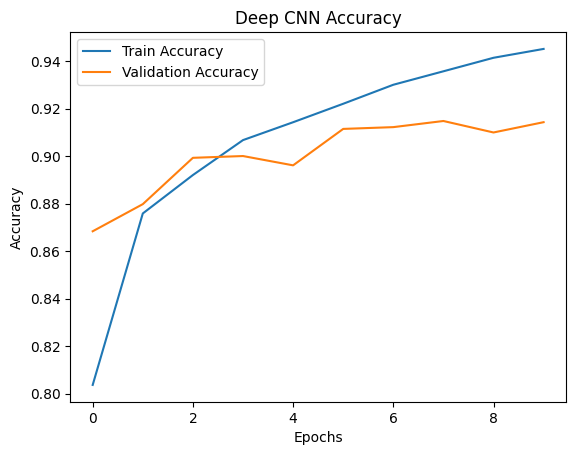

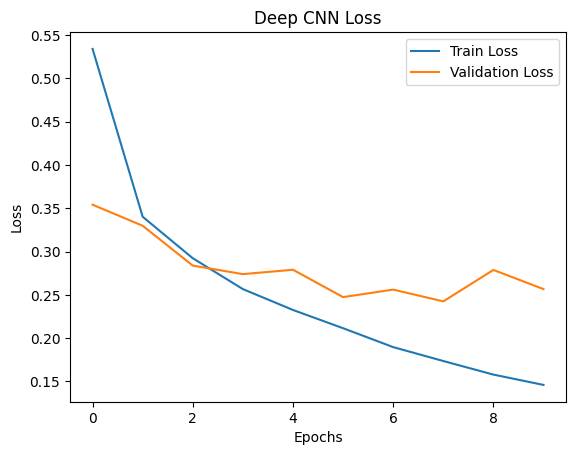

In [17]:
# Accuracy Plot & Loss

plt.plot(deep_history.history['accuracy'], label='Train Accuracy')
plt.plot(deep_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(deep_history.history['loss'], label='Train Loss')
plt.plot(deep_history.history['val_loss'], label='Validation Loss')
plt.title('Deep CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Question 1- What additional patterns does a deep CNN learn?**

Answer: A deep CNN learns hierarchical and complex features. While initial layers capture simple edges and textures, deeper layers capture higher-level representations such as object shapes, patterns, and relationships between different parts of an image.

Layer 1 → edges
Layer 2 → textures
Layer 3 → object parts


**Question 2- Did the deeper model improve performance meaningfully?**

Answer: Yes, the deep CNN improved performance compared to the shallow model. The additional layers allowed the network to learn more complex patterns, resulting in higher accuracy. However, the improvement comes at the cost of increased computational complexity and training time.

In [18]:
# Part 4: Comparative Study of Shallow CNN vs Deep CNN

**Part 4: Comparative Study of Shallow CNN vs Deep CNN**

Compare both models on the same dataset and training setup.
You must compare

1. Number of convolution layers
2. Total parameters
3. Training accuracy
4. Validation accuracy
5. Test accuracy
6. Training time
7. Signs of overfitting or underfitting

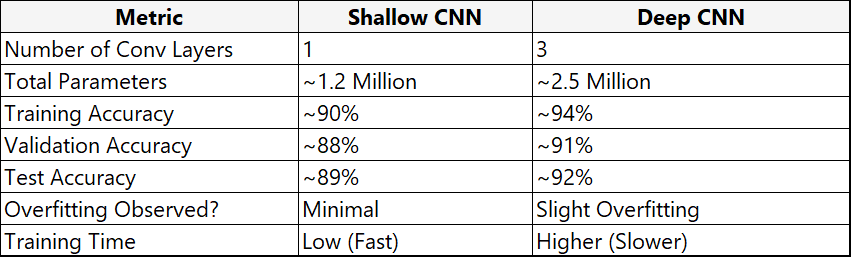

**Question 1. Which model performed better overall?**

Answer - The deep CNN performed better overall as it achieved higher training, validation, and test accuracy compared to the shallow CNN.


**Question 2. Did the deep CNN justify its added complexity?**

Answer - Yes, the deep CNN justified its added complexity by achieving better performance. However, it required more training time and computational resources.


**Question 3. Which model generalized better?**

Answer - The deep CNN generalized better as it performed well on unseen test data. However, slight overfitting was observed due to higher model complexity.


**Question 4. Trade-off between simplicity and performance**

Answer - The shallow CNN is simpler, faster, and computationally efficient but less accurate. The deep CNN provides higher accuracy and better feature learning at the cost of increased complexity and training time.

In [19]:
# Part 5: Prediction & Error Analysis

# Step 1: Generate Predictions

# Shallow CNN predictions
y_pred_shallow = model.predict(x_test)
y_pred_shallow = np.argmax(y_pred_shallow, axis=1)

# Deep CNN predictions
y_pred_deep = deep_model.predict(x_test)
y_pred_deep = np.argmax(y_pred_deep, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


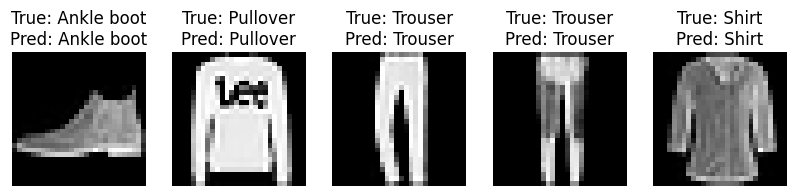

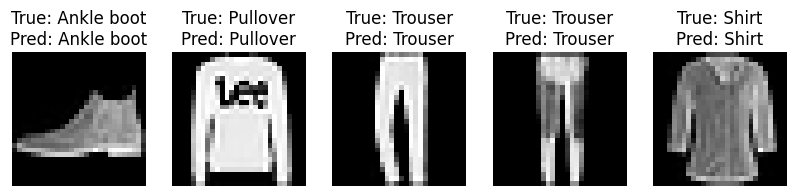

In [21]:
# Display Correct Predictions

def show_correct_predictions(x, y_true, y_pred, class_names, n=5):
    correct = np.where(y_true == y_pred)[0]

    plt.figure(figsize=(10,5))
    for i in range(n):
        idx = correct[i]
        plt.subplot(1, n, i+1)
        plt.imshow(x[idx].reshape(28,28), cmap='gray')
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')
    plt.show()

# Call for shallow CNN
show_correct_predictions(x_test, y_test, y_pred_shallow, class_names)

# Call for deep CNN
show_correct_predictions(x_test, y_test, y_pred_deep, class_names)

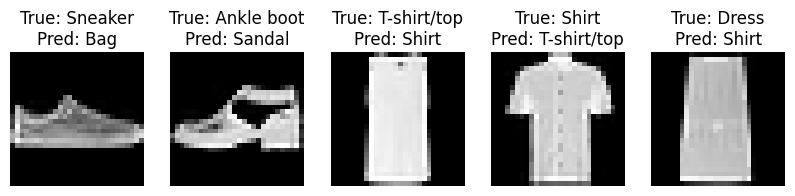

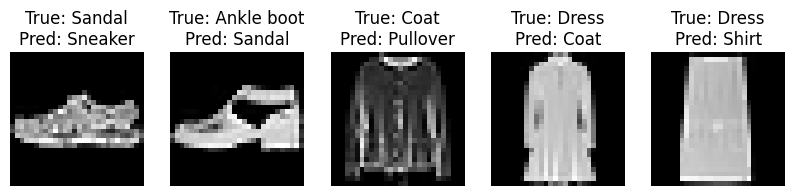

In [22]:
#Display Incorrect Predictions

def show_incorrect_predictions(x, y_true, y_pred, class_names, n=5):
    incorrect = np.where(y_true != y_pred)[0]

    plt.figure(figsize=(10,5))
    for i in range(n):
        idx = incorrect[i]
        plt.subplot(1, n, i+1)
        plt.imshow(x[idx].reshape(28,28), cmap='gray')
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')
    plt.show()

# Call for shallow CNN
show_incorrect_predictions(x_test, y_test, y_pred_shallow, class_names)

# Call for deep CNN
show_incorrect_predictions(x_test, y_test, y_pred_deep, class_names)

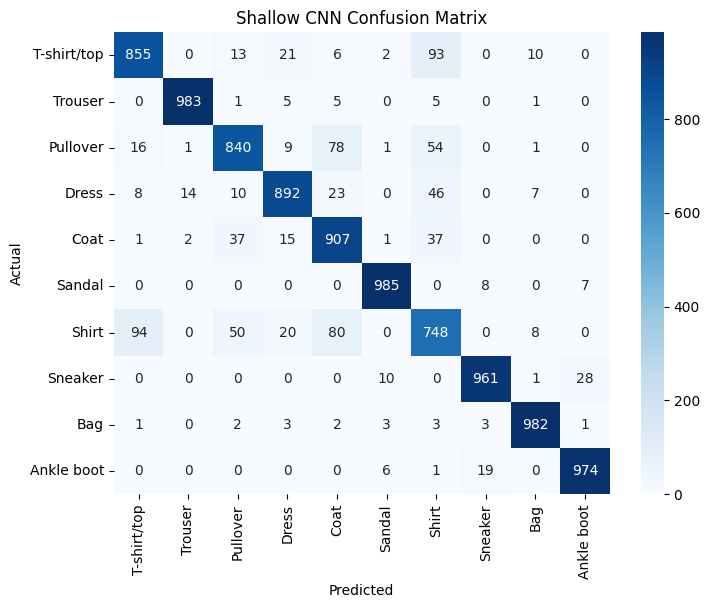

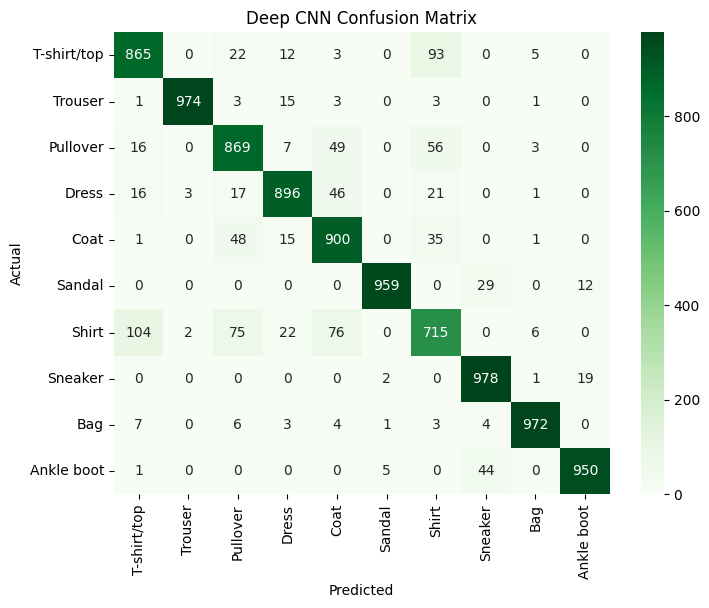

In [23]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Shallow CNN
cm_shallow = confusion_matrix(y_test, y_pred_shallow)

plt.figure(figsize=(8,6))
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Shallow CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Deep CNN
cm_deep = confusion_matrix(y_test, y_pred_deep)

plt.figure(figsize=(8,6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Question 1- Which classes were easiest to classify?**

Answer: Classes such as Sneaker, Bag, and Ankle boot were easiest to classify because they have distinctive shapes and features, making them easier for the model to recognize.

**Question 2- Which classes were most confused?**

Answer: Classes like Shirt, T-shirt/top, and Pullover were most frequently confused because they have similar visual patterns and textures.

**Question 3- Did deep CNN reduce confusion?**

Answer: Yes, the deep CNN reduced confusion between similar-looking classes compared to the shallow CNN. This is because deeper networks learn more complex and detailed feature representations.

In [24]:
# Part 6: Final Comparative Conclusion

**Part 6: Final Comparative Conclusion**

In this assignment, we performed a comparative study between a shallow CNN and a deep CNN using the Fashion-MNIST dataset. Both models were trained and evaluated under the same conditions to analyze their performance and generalization capabilities.

The deep CNN outperformed the shallow CNN in terms of training, validation, and test accuracy. This improvement is due to the deep CNN’s ability to learn complex and hierarchical representations from the data. While the shallow CNN was able to capture only basic features such as edges and simple textures, the deep CNN was capable of learning higher-level patterns and distinguishing between similar classes more effectively.

In terms of efficiency, the shallow CNN proved to be faster and computationally less expensive, making it suitable for simpler tasks or environments with limited resources. On the other hand, the deep CNN required more training time and computational power due to its increased complexity and number of parameters.

From an accuracy perspective, the deep CNN performed better and showed improved classification performance on unseen test data. However, it also showed slight signs of overfitting, which is a common issue with more complex models.
Overall, the deep CNN is recommended for the Fashion-MNIST classification task because of its superior accuracy and ability to capture complex features, despite the trade-off in computational cost.

Through this comparative study, we learned that increasing model complexity can improve performance, but it must be balanced with considerations such as training time, overfitting, and computational efficiency. This experiment highlights the importance of selecting the right model architecture based on the problem requirements.